# 06 - Detector de defectos mejorado (NEU-DET)

Mejoras incluidas:
- Data augmentation con albumentations (flip H/V + brillo, p=0.5) con transformación consistente de bboxes.
- Loss de localización con CIoU + Focal Loss binaria para confianza (gamma=2.0, alpha=0.25).
- Backbone ajustado para salida de rejilla 14x14 con entrada 224x224.
- Bloque residual en la última etapa del backbone.
- Scheduler CosineAnnealingLR.
- Post-procesado NMS más estricto (IoU=0.30).
- Análisis en TEST: métricas estilo YOLO y matriz de confusión.

## 1) Imports y configuración

In [20]:
from pathlib import Path
from typing import List, Optional, Sequence, Tuple
from contextlib import nullcontext
import platform
import subprocess
import sys

import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt

try:
    import albumentations as A
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "albumentations", "-q"])
    import albumentations as A

print(f"Python activo: {platform.python_version()} | Kernel esperado: tfm_steel_311")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {DEVICE}")

NEU_CLASSES = [
    "crazing",
    "inclusion",
    "patches",
    "pitted_surface",
    "rolled-in_scale",
    "scratches",
]
NUM_CLASSES = len(NEU_CLASSES)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

Python activo: 3.11.15 | Kernel esperado: tfm_steel_311
Dispositivo: cuda


## 2) Dataset con Albumentations (bbox-safe)

In [21]:
class NEUGridDatasetAug(Dataset):
    """
    Dataset para etiquetas YOLO co-localizadas con imágenes.
    Formato txt: class x_center y_center width height (normalizado).
    """

    def __init__(
        self,
        split_dir: Path,
        image_size: int = 224,
        s: int = 7,
        num_classes: int = 6,
        use_augmentation: bool = True,
    ) -> None:
        self.split_dir = split_dir
        self.image_size = image_size
        self.s = s
        self.num_classes = num_classes

        self.valid_ext = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}
        all_label_files = sorted(self.split_dir.rglob("*.txt"))
        if not all_label_files:
            raise FileNotFoundError(f"No hay etiquetas en: {self.split_dir}")

        self.samples: List[Tuple[Path, Path]] = []
        skipped = 0
        for label_path in all_label_files:
            image_path = self._find_image_for_label(label_path, raise_if_missing=False)
            if image_path is None:
                skipped += 1
                continue
            self.samples.append((label_path, image_path))

        if not self.samples:
            raise FileNotFoundError(
                f"No se encontraron pares válidos imagen-etiqueta en: {self.split_dir} "
                f"(labels={len(all_label_files)}, skipped={skipped})"
            )

        if skipped > 0:
            print(f"[WARN] Etiquetas sin imagen asociada ignoradas: {skipped}")
        print(f"Dataset listo: {len(self.samples)} muestras válidas")

        if use_augmentation:
            self.transform = A.Compose(
                [
                    A.HorizontalFlip(p=0.5),
                    A.VerticalFlip(p=0.5),
                    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.0, p=0.5),
                    A.Resize(height=self.image_size, width=self.image_size),
                ],
                bbox_params=A.BboxParams(format="yolo", label_fields=["class_labels"], min_visibility=0.0),
            )
        else:
            self.transform = A.Compose(
                [A.Resize(height=self.image_size, width=self.image_size)],
                bbox_params=A.BboxParams(format="yolo", label_fields=["class_labels"], min_visibility=0.0),
            )

    def __len__(self) -> int:
        return len(self.samples)

    def _find_image_for_label(self, label_path: Path, raise_if_missing: bool = True) -> Optional[Path]:
        stem = label_path.stem

        for c in sorted(label_path.parent.glob(f"{stem}.*")):
            if c.suffix.lower() in self.valid_ext and c.is_file():
                return c

        for c in sorted(self.split_dir.rglob(f"{stem}.*")):
            if c.suffix.lower() in self.valid_ext and c.is_file():
                return c

        if raise_if_missing:
            raise FileNotFoundError(f"No se encontró imagen para etiqueta: {label_path}")
        return None

    def _read_boxes(self, label_path: Path) -> List[Tuple[int, float, float, float, float]]:
        boxes = []
        for line in label_path.read_text(encoding="utf-8").splitlines():
            if not line.strip():
                continue
            c, x, y, w, h = line.split()
            boxes.append((int(c), float(x), float(y), float(w), float(h)))
        return boxes

    def _build_target(self, boxes: Sequence[Tuple[int, float, float, float, float]]) -> torch.Tensor:
        target = torch.zeros((self.s, self.s, 5 + self.num_classes), dtype=torch.float32)

        for class_id, x_center, y_center, width, height in boxes:
            gx = x_center * self.s
            gy = y_center * self.s
            j = min(self.s - 1, max(0, int(gx)))
            i = min(self.s - 1, max(0, int(gy)))

            x_cell = gx - j
            y_cell = gy - i

            if target[i, j, 0] > 0:
                prev_w = float(target[i, j, 3].item())
                prev_h = float(target[i, j, 4].item())
                if prev_w * prev_h >= width * height:
                    continue

            target[i, j, 0] = 1.0
            target[i, j, 1] = x_cell
            target[i, j, 2] = y_cell
            target[i, j, 3] = width
            target[i, j, 4] = height
            target[i, j, 5:] = 0.0
            if 0 <= class_id < self.num_classes:
                target[i, j, 5 + class_id] = 1.0

        return target

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        label_path, image_path = self.samples[idx]

        img_bgr = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
        if img_bgr is None:
            raise ValueError(f"No se pudo leer imagen: {image_path}")

        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        raw_boxes = self._read_boxes(label_path)
        bboxes_yolo = [(x, y, w, h) for _, x, y, w, h in raw_boxes]
        class_labels = [c for c, _, _, _, _ in raw_boxes]

        transformed = self.transform(image=img_rgb, bboxes=bboxes_yolo, class_labels=class_labels)
        img_aug = transformed["image"].astype(np.float32) / 255.0

        aug_boxes = []
        for (x, y, w, h), c in zip(transformed["bboxes"], transformed["class_labels"]):
            aug_boxes.append((int(c), float(x), float(y), float(w), float(h)))

        mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
        std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
        img_aug = (img_aug - mean) / std

        image_tensor = torch.from_numpy(img_aug).permute(2, 0, 1).contiguous()
        target_tensor = self._build_target(aug_boxes)
        return image_tensor, target_tensor

## 3) Arquitectura mejorada (Residual Block)

In [22]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, use_pool: bool = True) -> None:
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(negative_slope=0.1, inplace=True),
        ]
        if use_pool:
            layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
        self.block = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)


class ResidualBlock(nn.Module):
    def __init__(self, channels: int) -> None:
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(channels)
        self.act = nn.LeakyReLU(negative_slope=0.1, inplace=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        identity = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.act(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out = out + identity
        out = self.act(out)
        return out


class CustomSteelDetectorImproved(nn.Module):
    def __init__(self, s: int = 14, num_classes: int = 6) -> None:
        super().__init__()
        self.s = s
        self.num_classes = num_classes

        self.backbone = nn.Sequential(
            ConvBlock(3, 32, use_pool=True),
            ConvBlock(32, 64, use_pool=True),
            ConvBlock(64, 128, use_pool=True),
            ConvBlock(128, 256, use_pool=True),
            ConvBlock(256, 512, use_pool=False),
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(negative_slope=0.1, inplace=True),
            ResidualBlock(512),
        )

        self.head = nn.Conv2d(512, 5 + num_classes, kernel_size=1, stride=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.backbone(x)
        x = self.head(x)
        x = x.permute(0, 2, 3, 1)
        return x

## 4) Loss mejorada (CIoU + Focal conf + class)

In [31]:
def _xywh_to_xyxy(xc: torch.Tensor, yc: torch.Tensor, w: torch.Tensor, h: torch.Tensor):
    x1 = xc - w / 2.0
    y1 = yc - h / 2.0
    x2 = xc + w / 2.0
    y2 = yc + h / 2.0
    return x1, y1, x2, y2


def ciou_loss_xywh(pred_xywh: torch.Tensor, tgt_xywh: torch.Tensor, eps: float = 1e-7) -> torch.Tensor:
    px, py, pw, ph = pred_xywh.unbind(dim=-1)
    tx, ty, tw, th = tgt_xywh.unbind(dim=-1)

    p_x1, p_y1, p_x2, p_y2 = _xywh_to_xyxy(px, py, pw, ph)
    t_x1, t_y1, t_x2, t_y2 = _xywh_to_xyxy(tx, ty, tw, th)

    inter_x1 = torch.maximum(p_x1, t_x1)
    inter_y1 = torch.maximum(p_y1, t_y1)
    inter_x2 = torch.minimum(p_x2, t_x2)
    inter_y2 = torch.minimum(p_y2, t_y2)

    inter_w = torch.clamp(inter_x2 - inter_x1, min=0.0)
    inter_h = torch.clamp(inter_y2 - inter_y1, min=0.0)
    inter_area = inter_w * inter_h

    p_area = torch.clamp(p_x2 - p_x1, min=0.0) * torch.clamp(p_y2 - p_y1, min=0.0)
    t_area = torch.clamp(t_x2 - t_x1, min=0.0) * torch.clamp(t_y2 - t_y1, min=0.0)
    union = p_area + t_area - inter_area + eps

    iou = inter_area / union

    p_cx = (p_x1 + p_x2) / 2.0
    p_cy = (p_y1 + p_y2) / 2.0
    t_cx = (t_x1 + t_x2) / 2.0
    t_cy = (t_y1 + t_y2) / 2.0

    center_dist_sq = (p_cx - t_cx) ** 2 + (p_cy - t_cy) ** 2

    c_x1 = torch.minimum(p_x1, t_x1)
    c_y1 = torch.minimum(p_y1, t_y1)
    c_x2 = torch.maximum(p_x2, t_x2)
    c_y2 = torch.maximum(p_y2, t_y2)
    c_diag_sq = (c_x2 - c_x1) ** 2 + (c_y2 - c_y1) ** 2 + eps

    v = (4.0 / (np.pi**2)) * torch.pow(torch.atan(tw / (th + eps)) - torch.atan(pw / (ph + eps)), 2)
    alpha = v / (1.0 - iou + v + eps)

    ciou = iou - (center_dist_sq / c_diag_sq) - alpha * v
    loss = 1.0 - ciou
    loss = torch.nan_to_num(loss, nan=1.0, posinf=1.0, neginf=1.0)
    return loss.mean()


def binary_focal_loss_from_logits(
    logits: torch.Tensor,
    targets: torch.Tensor,
    alpha: float = 0.25,
    gamma: float = 2.0,
    reduction: str = "mean",
) -> torch.Tensor:
    logits = torch.nan_to_num(logits, nan=0.0, posinf=20.0, neginf=-20.0)
    logits = torch.clamp(logits, min=-20.0, max=20.0)
    targets = torch.nan_to_num(targets, nan=0.0, posinf=1.0, neginf=0.0)

    bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
    p = torch.sigmoid(logits)
    p_t = p * targets + (1.0 - p) * (1.0 - targets)
    p_t = torch.clamp(p_t, min=1e-6, max=1.0 - 1e-6)

    alpha_t = alpha * targets + (1.0 - alpha) * (1.0 - targets)
    focal = alpha_t * ((1.0 - p_t) ** gamma) * bce
    focal = torch.nan_to_num(focal, nan=0.0, posinf=0.0, neginf=0.0)

    if reduction == "mean":
        return focal.mean()
    if reduction == "sum":
        return focal.sum()
    return focal


class CustomDetectionLossCIoU(nn.Module):
    def __init__(
        self,
        s: int = 14,
        lambda_coord: float = 5.0,
        lambda_obj: float = 1.0,
        lambda_noobj: float = 0.5,
        lambda_cls: float = 1.0,
        focal_alpha: float = 0.25,
        focal_gamma: float = 2.0,
    ) -> None:
        super().__init__()
        self.s = s
        self.lambda_coord = lambda_coord
        self.lambda_obj = lambda_obj
        self.lambda_noobj = lambda_noobj
        self.lambda_cls = lambda_cls
        self.focal_alpha = focal_alpha
        self.focal_gamma = focal_gamma

    def forward(self, preds: torch.Tensor, target: torch.Tensor):
        obj_mask = target[..., 0] > 0.5
        noobj_mask = ~obj_mask

        pred_conf_logits = torch.nan_to_num(preds[..., 0], nan=0.0, posinf=20.0, neginf=-20.0)
        pred_xywh_raw = torch.sigmoid(torch.nan_to_num(preds[..., 1:5], nan=0.0, posinf=20.0, neginf=-20.0))
        pred_cls = torch.nan_to_num(preds[..., 5:], nan=0.0, posinf=20.0, neginf=-20.0)

        tgt_conf = target[..., 0]

        loss_coord = torch.tensor(0.0, device=preds.device)
        loss_obj = torch.tensor(0.0, device=preds.device)
        loss_noobj = torch.tensor(0.0, device=preds.device)
        loss_cls = torch.tensor(0.0, device=preds.device)

        if obj_mask.any():
            s = self.s
            b = preds.shape[0]
            y_grid, x_grid = torch.meshgrid(
                torch.arange(s, device=preds.device),
                torch.arange(s, device=preds.device),
                indexing="ij",
            )
            x_grid = x_grid.unsqueeze(0).expand(b, -1, -1)
            y_grid = y_grid.unsqueeze(0).expand(b, -1, -1)

            pred_x = (pred_xywh_raw[..., 0] + x_grid) / s
            pred_y = (pred_xywh_raw[..., 1] + y_grid) / s
            pred_w = pred_xywh_raw[..., 2]
            pred_h = pred_xywh_raw[..., 3]

            tgt_x = (target[..., 1] + x_grid) / s
            tgt_y = (target[..., 2] + y_grid) / s
            tgt_w = target[..., 3]
            tgt_h = target[..., 4]

            pred_xywh_global = torch.stack([pred_x, pred_y, pred_w, pred_h], dim=-1)[obj_mask]
            tgt_xywh_global = torch.stack([tgt_x, tgt_y, tgt_w, tgt_h], dim=-1)[obj_mask]

            loss_coord = ciou_loss_xywh(pred_xywh_global, tgt_xywh_global)
            loss_obj = binary_focal_loss_from_logits(
                pred_conf_logits[obj_mask],
                tgt_conf[obj_mask],
                alpha=self.focal_alpha,
                gamma=self.focal_gamma,
                reduction="mean",
            )

            target_cls_idx = torch.argmax(target[..., 5:], dim=-1)
            loss_cls = F.cross_entropy(pred_cls[obj_mask], target_cls_idx[obj_mask], reduction="mean")
            loss_cls = torch.nan_to_num(loss_cls, nan=0.0, posinf=0.0, neginf=0.0)

        if noobj_mask.any():
            loss_noobj = binary_focal_loss_from_logits(
                pred_conf_logits[noobj_mask],
                tgt_conf[noobj_mask],
                alpha=self.focal_alpha,
                gamma=self.focal_gamma,
                reduction="mean",
            )

        total = (
            self.lambda_coord * loss_coord
            + self.lambda_obj * loss_obj
            + self.lambda_noobj * loss_noobj
            + self.lambda_cls * loss_cls
        )
        total = torch.nan_to_num(total, nan=0.0, posinf=0.0, neginf=0.0)

        parts = {
            "total": total.detach(),
            "coord": loss_coord.detach(),
            "class": loss_cls.detach(),
            "conf": (loss_obj + loss_noobj).detach(),
        }
        return total, parts

## 5) Entrenamiento mejorado (CosineAnnealingLR + curvas de loss)

Dataset listo: 1439 muestras válidas
Epoch 001/100 | total=3.71144 | coord(CIoU)=0.57879 | class=0.71604 | conf(Focal)=0.15455 | skip=0 | lr=0.0002999
Epoch 002/100 | total=2.95887 | coord(CIoU)=0.49625 | class=0.39031 | conf(Focal)=0.12974 | skip=0 | lr=0.0002997
Epoch 003/100 | total=2.74988 | coord(CIoU)=0.46798 | class=0.32829 | conf(Focal)=0.12159 | skip=0 | lr=0.0002993
Epoch 004/100 | total=2.55212 | coord(CIoU)=0.44123 | class=0.26931 | conf(Focal)=0.11389 | skip=0 | lr=0.0002988
Epoch 005/100 | total=2.39355 | coord(CIoU)=0.41853 | class=0.22636 | conf(Focal)=0.11099 | skip=0 | lr=0.0002982
Epoch 006/100 | total=2.30804 | coord(CIoU)=0.40666 | class=0.20233 | conf(Focal)=0.10792 | skip=0 | lr=0.0002974
Epoch 007/100 | total=2.21547 | coord(CIoU)=0.39309 | class=0.17899 | conf(Focal)=0.10631 | skip=0 | lr=0.0002964
Epoch 008/100 | total=2.15456 | coord(CIoU)=0.38554 | class=0.15706 | conf(Focal)=0.10418 | skip=0 | lr=0.0002953
Epoch 009/100 | total=2.03639 | coord(CIoU)=0.36820

Dataset listo: 1439 muestras válidas
Epoch 001/100 | total=3.71144 | coord(CIoU)=0.57879 | class=0.71604 | conf(Focal)=0.15455 | skip=0 | lr=0.0002999
Epoch 002/100 | total=2.95887 | coord(CIoU)=0.49625 | class=0.39031 | conf(Focal)=0.12974 | skip=0 | lr=0.0002997
Epoch 003/100 | total=2.74988 | coord(CIoU)=0.46798 | class=0.32829 | conf(Focal)=0.12159 | skip=0 | lr=0.0002993
Epoch 004/100 | total=2.55212 | coord(CIoU)=0.44123 | class=0.26931 | conf(Focal)=0.11389 | skip=0 | lr=0.0002988
Epoch 005/100 | total=2.39355 | coord(CIoU)=0.41853 | class=0.22636 | conf(Focal)=0.11099 | skip=0 | lr=0.0002982
Epoch 006/100 | total=2.30804 | coord(CIoU)=0.40666 | class=0.20233 | conf(Focal)=0.10792 | skip=0 | lr=0.0002974
Epoch 007/100 | total=2.21547 | coord(CIoU)=0.39309 | class=0.17899 | conf(Focal)=0.10631 | skip=0 | lr=0.0002964
Epoch 008/100 | total=2.15456 | coord(CIoU)=0.38554 | class=0.15706 | conf(Focal)=0.10418 | skip=0 | lr=0.0002953
Epoch 009/100 | total=2.03639 | coord(CIoU)=0.36820

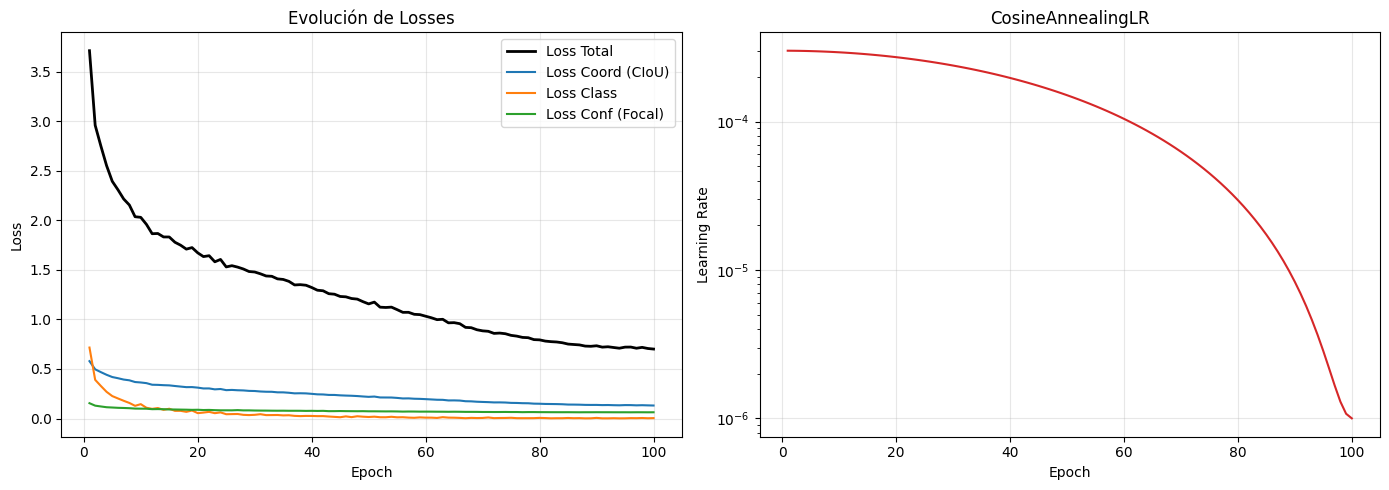

Curvas guardadas en: C:\Users\Usuario\Desktop\TFM_CNN_Custom\resultados\detector_mejorado\curvas_loss_detector_mejorado.png
Batches descartados por inestabilidad (total): 0


In [32]:
def get_amp_tools(device: torch.device):
    if device.type != "cuda":
        return None, None, nullcontext

    try:
        autocast_fn = torch.amp.autocast
        scaler_obj = torch.amp.GradScaler("cuda")

        def autocast_ctx():
            return autocast_fn(device_type="cuda", dtype=torch.float16)

        return autocast_fn, scaler_obj, autocast_ctx
    except (AttributeError, TypeError):
        autocast_fn = torch.cuda.amp.autocast
        scaler_obj = torch.cuda.amp.GradScaler()

        def autocast_ctx():
            return autocast_fn(dtype=torch.float16)

        return autocast_fn, scaler_obj, autocast_ctx


def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
    scaler: Optional[object],
    autocast_ctx,
    grad_clip_norm: float = 5.0,
) -> dict:
    model.train()

    sum_total = 0.0
    sum_coord = 0.0
    sum_class = 0.0
    sum_conf = 0.0

    n = 0
    skipped_batches = 0

    for images, targets in loader:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        if not torch.isfinite(images).all() or not torch.isfinite(targets).all():
            skipped_batches += 1
            continue

        optimizer.zero_grad(set_to_none=True)

        if scaler is not None:
            with autocast_ctx():
                preds = model(images)
                total_loss, parts = criterion(preds, targets)

            if not torch.isfinite(total_loss):
                skipped_batches += 1
                continue

            scaler.scale(total_loss).backward()
            scaler.unscale_(optimizer)
            grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip_norm)

            if not torch.isfinite(grad_norm):
                skipped_batches += 1
                optimizer.zero_grad(set_to_none=True)
                scaler.update()
                continue

            scaler.step(optimizer)
            scaler.update()
        else:
            preds = model(images)
            total_loss, parts = criterion(preds, targets)

            if not torch.isfinite(total_loss):
                skipped_batches += 1
                continue

            total_loss.backward()
            grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip_norm)
            if not torch.isfinite(grad_norm):
                skipped_batches += 1
                optimizer.zero_grad(set_to_none=True)
                continue
            optimizer.step()

        bs = images.size(0)
        n += bs
        sum_total += float(parts["total"].item()) * bs
        sum_coord += float(parts["coord"].item()) * bs
        sum_class += float(parts["class"].item()) * bs
        sum_conf += float(parts["conf"].item()) * bs

    if n == 0:
        raise RuntimeError("Todos los batches fueron descartados por inestabilidad numérica.")

    return {
        "total": sum_total / max(1, n),
        "coord": sum_coord / max(1, n),
        "class": sum_class / max(1, n),
        "conf": sum_conf / max(1, n),
        "skipped": skipped_batches,
    }


def save_checkpoint(model: nn.Module, class_names: Sequence[str], s: int, image_size: int, save_path: Path) -> None:
    save_path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "class_names": list(class_names),
            "s": s,
            "num_classes": len(class_names),
            "image_size": image_size,
        },
        save_path,
    )


TRAIN_DIR = Path("../data/clasificacion_full")
EPOCHS = 100
BATCH_SIZE = 16
NUM_WORKERS = 0
LR = 3e-4
IMAGE_SIZE = 224
GRID_SIZE = 14
USE_AMP = False
GRAD_CLIP_NORM = 5.0
SAVE_PATH = Path("../src/custom_steel_detector_grid14_mejorado.pth")
RESULTS_DIR = Path("../resultados/detector_mejorado")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

dataset = NEUGridDatasetAug(
    split_dir=TRAIN_DIR,
    image_size=IMAGE_SIZE,
    s=GRID_SIZE,
    num_classes=NUM_CLASSES,
    use_augmentation=True,
)

loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    drop_last=False,
)

model = CustomSteelDetectorImproved(s=GRID_SIZE, num_classes=NUM_CLASSES).to(DEVICE)
criterion = CustomDetectionLossCIoU(
    s=GRID_SIZE,
    lambda_coord=5.0,
    lambda_obj=1.0,
    lambda_noobj=0.5,
    lambda_cls=1.0,
    focal_alpha=0.25,
    focal_gamma=2.0,
)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
_, scaler_auto, autocast_ctx_auto = get_amp_tools(DEVICE)
if USE_AMP and DEVICE.type == "cuda":
    scaler, autocast_ctx = scaler_auto, autocast_ctx_auto
else:
    scaler, autocast_ctx = None, nullcontext

history = {
    "total": [],
    "coord": [],
    "class": [],
    "conf": [],
    "lr": [],
    "skipped": [],
}

for epoch in range(1, EPOCHS + 1):
    losses = train_one_epoch(
        model,
        loader,
        criterion,
        optimizer,
        DEVICE,
        scaler,
        autocast_ctx,
        grad_clip_norm=GRAD_CLIP_NORM,
    )
    scheduler.step()

    history["total"].append(losses["total"])
    history["coord"].append(losses["coord"])
    history["class"].append(losses["class"])
    history["conf"].append(losses["conf"])
    history["lr"].append(optimizer.param_groups[0]["lr"])
    history["skipped"].append(losses["skipped"])

    print(
        f"Epoch {epoch:03d}/{EPOCHS} | "
        f"total={losses['total']:.5f} | coord(CIoU)={losses['coord']:.5f} | "
        f"class={losses['class']:.5f} | conf(Focal)={losses['conf']:.5f} | "
        f"skip={losses['skipped']} | lr={optimizer.param_groups[0]['lr']:.7f}"
    )

if any(not np.isfinite(x) for x in history["total"]):
    print("[WARN] Se detectaron pérdidas no finitas. No se guarda checkpoint para evitar contaminar evaluación.")
else:
    save_checkpoint(model, NEU_CLASSES, GRID_SIZE, IMAGE_SIZE, SAVE_PATH)
    print(f"Modelo mejorado guardado en: {SAVE_PATH.resolve()}")

epochs = np.arange(1, len(history["total"]) + 1)
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, history['total'], label='Loss Total', color='black', linewidth=2)
plt.plot(epochs, history['coord'], label='Loss Coord (CIoU)', color='tab:blue')
plt.plot(epochs, history['class'], label='Loss Class', color='tab:orange')
plt.plot(epochs, history['conf'], label='Loss Conf (Focal)', color='tab:green')
plt.title('Evolución de Losses')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history['lr'], color='tab:red')
plt.title('CosineAnnealingLR')
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.yscale('log')
plt.grid(alpha=0.3)
plt.tight_layout()

loss_plot_path = RESULTS_DIR / 'curvas_loss_detector_mejorado.png'
plt.savefig(loss_plot_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Curvas guardadas en: {loss_plot_path.resolve()}")

if len(history['skipped']) > 0:
    print(f"Batches descartados por inestabilidad (total): {int(np.sum(history['skipped']))}")

## 6) Inferencia rápida con NMS

In [44]:
def iou_xyxy(box_a, box_b) -> float:
    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b

    inter_x1 = max(ax1, bx1)
    inter_y1 = max(ay1, by1)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)

    inter_w = max(0, inter_x2 - inter_x1)
    inter_h = max(0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h

    area_a = max(0, ax2 - ax1) * max(0, ay2 - ay1)
    area_b = max(0, bx2 - bx1) * max(0, by2 - by1)
    union = area_a + area_b - inter_area
    return 0.0 if union <= 0 else inter_area / union


def nms_per_class(dets: List[Tuple[float, int, int, int, int, int]], iou_thr: float = 0.30):
    kept = []
    by_class = {}
    for d in dets:
        by_class.setdefault(d[1], []).append(d)

    for _, class_dets in by_class.items():
        class_dets = sorted(class_dets, key=lambda x: x[0], reverse=True)
        while class_dets:
            best = class_dets.pop(0)
            kept.append(best)
            best_box = (best[2], best[3], best[4], best[5])
            remain = []
            for d in class_dets:
                cur_box = (d[2], d[3], d[4], d[5])
                if iou_xyxy(best_box, cur_box) < iou_thr:
                    remain.append(d)
            class_dets = remain

    return sorted(kept, key=lambda x: x[0], reverse=True)


def decode_predictions(pred_grid: torch.Tensor, threshold: float, s: int, image_w: int, image_h: int, nms_iou_thr: float = 0.30):
    dets = []
    pred_grid = pred_grid.detach().cpu()

    for i in range(s):
        for j in range(s):
            conf = torch.sigmoid(pred_grid[i, j, 0]).item()
            if not np.isfinite(conf) or conf < threshold:
                continue

            x_cell = torch.sigmoid(pred_grid[i, j, 1]).item()
            y_cell = torch.sigmoid(pred_grid[i, j, 2]).item()
            w_norm = torch.sigmoid(pred_grid[i, j, 3]).item()
            h_norm = torch.sigmoid(pred_grid[i, j, 4]).item()

            if not (np.isfinite(x_cell) and np.isfinite(y_cell) and np.isfinite(w_norm) and np.isfinite(h_norm)):
                continue

            class_logits = pred_grid[i, j, 5:]
            if not torch.isfinite(class_logits).all().item():
                continue

            class_id = int(torch.argmax(class_logits).item())

            x_center = (j + x_cell) / s
            y_center = (i + y_cell) / s

            x1_f = (x_center - w_norm / 2.0) * image_w
            y1_f = (y_center - h_norm / 2.0) * image_h
            x2_f = (x_center + w_norm / 2.0) * image_w
            y2_f = (y_center + h_norm / 2.0) * image_h

            if not (np.isfinite(x1_f) and np.isfinite(y1_f) and np.isfinite(x2_f) and np.isfinite(y2_f)):
                continue

            x1 = int(x1_f)
            y1 = int(y1_f)
            x2 = int(x2_f)
            y2 = int(y2_f)

            x1 = max(0, min(image_w - 1, x1))
            y1 = max(0, min(image_h - 1, y1))
            x2 = max(0, min(image_w - 1, x2))
            y2 = max(0, min(image_h - 1, y2))
            if x2 <= x1 or y2 <= y1:
                continue

            dets.append((conf, class_id, x1, y1, x2, y2))

    return nms_per_class(dets, iou_thr=nms_iou_thr)


def run_inference(weights: Path, image_path: Path, output_path: Path, threshold: float = 0.35, nms_iou_thr: float = 0.30) -> None:
    ckpt = torch.load(weights, map_location=DEVICE)
    class_names = ckpt.get("class_names", NEU_CLASSES)
    s = int(ckpt.get("s", 14))
    num_classes = int(ckpt.get("num_classes", len(class_names)))
    image_size = int(ckpt.get("image_size", 224))

    model = CustomSteelDetectorImproved(s=s, num_classes=num_classes).to(DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    raw = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
    if raw is None:
        raise ValueError(f"No se pudo leer imagen: {image_path}")

    h, w = raw.shape[:2]
    rgb = cv2.cvtColor(raw, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(rgb, (image_size, image_size), interpolation=cv2.INTER_LINEAR).astype(np.float32) / 255.0

    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
    resized = (resized - mean) / std

    x = torch.from_numpy(resized).permute(2, 0, 1).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        pred = model(x)[0]

    dets = decode_predictions(pred, threshold, s, image_size, image_size, nms_iou_thr=nms_iou_thr)

    sx = w / float(image_size)
    sy = h / float(image_size)

    vis = raw.copy()
    for conf, class_id, x1, y1, x2, y2 in dets:
        rx1 = int(x1 * sx)
        ry1 = int(y1 * sy)
        rx2 = int(x2 * sx)
        ry2 = int(y2 * sy)

        cv2.rectangle(vis, (rx1, ry1), (rx2, ry2), (0, 255, 0), 2)
        class_name = class_names[class_id] if class_id < len(class_names) else str(class_id)
        cv2.putText(vis, f"{class_name}:{conf:.2f}", (rx1, max(12, ry1 - 6)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

    output_path.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(output_path), vis)
    print(f"Detecciones tras NMS: {len(dets)}")
    print(f"Resultado guardado en: {output_path.resolve()}")


WEIGHTS = Path("../src/custom_steel_detector_grid14_mejorado.pth")
TEST_IMAGE = Path("../data/test/crazing/ejemplo.jpg")
OUTPUT_IMAGE = Path("../resultados/deteccion_test_mejorado.jpg")
THRESHOLD = 0.35
NMS_IOU_THR = 0.30

# run_inference(WEIGHTS, TEST_IMAGE, OUTPUT_IMAGE, THRESHOLD, NMS_IOU_THR)

## 7) Evaluación en TEST (estilo YOLO + matriz de confusión)

=== Evaluación tipo YOLO (TEST) - MODELO MEJORADO ===
Imágenes evaluadas: 180
Precision global: 0.5357
Recall global:    0.7127
F1 global:        0.6117
mAP@0.5:          0.5685
IoU medio (TP):   0.7098

--- Métricas por clase ---
crazing          | P=0.3300 R=0.4459 F1=0.3793 AP50=0.2424 GT=74
inclusion        | P=0.5089 R=0.7611 F1=0.6099 AP50=0.5188 GT=113
patches          | P=0.6961 R=0.8875 F1=0.7802 AP50=0.8009 GT=80
pitted_surface   | P=0.6842 R=0.7879 F1=0.7324 AP50=0.7010 GT=33
rolled-in_scale  | P=0.4393 R=0.6267 F1=0.5165 AP50=0.4130 GT=75
scratches        | P=0.7222 R=0.7761 F1=0.7482 AP50=0.7349 GT=67


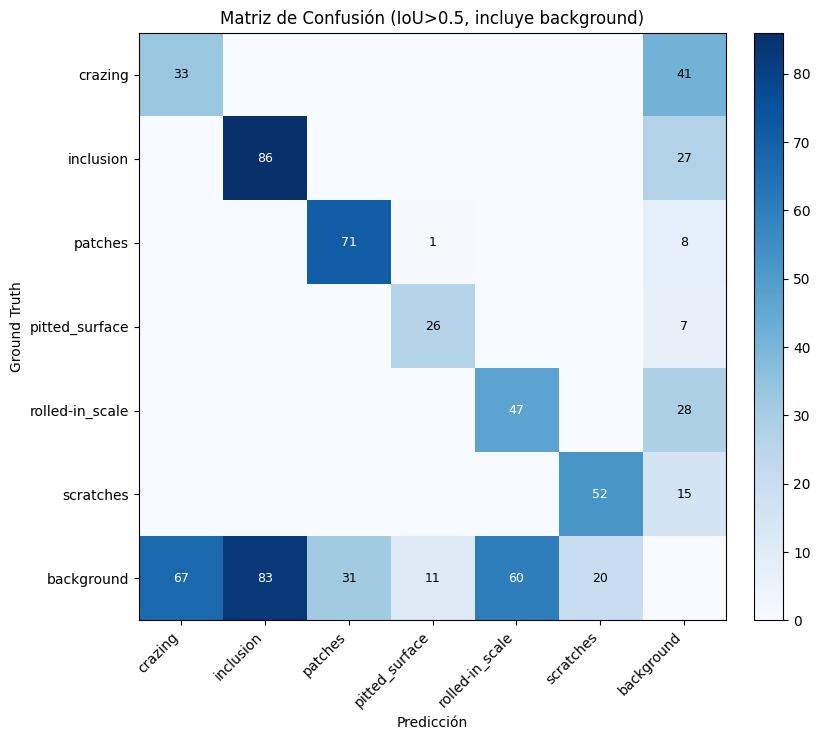

Matriz de confusión guardada en: C:\Users\Usuario\Desktop\TFM_CNN_Custom\resultados\detector_mejorado\matriz_confusion_test_mejorado.png


In [9]:
def _box_iou_np(box_a, box_b) -> float:
    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b

    inter_x1 = max(ax1, bx1)
    inter_y1 = max(ay1, by1)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)

    inter_w = max(0, inter_x2 - inter_x1)
    inter_h = max(0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h

    area_a = max(0, ax2 - ax1) * max(0, ay2 - ay1)
    area_b = max(0, bx2 - bx1) * max(0, by2 - by1)
    union = area_a + area_b - inter_area
    return 0.0 if union <= 0 else inter_area / union


def _list_test_images(test_root: Path) -> List[Path]:
    valid_ext = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}
    return sorted([p for p in test_root.rglob("*") if p.is_file() and p.suffix.lower() in valid_ext])


def _read_gt_boxes(image_path: Path, class_names: Sequence[str]):
    label_path = image_path.with_suffix(".txt")
    if not label_path.exists():
        return []

    img = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
    if img is None:
        return []
    h, w = img.shape[:2]

    out = []
    with open(label_path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            cls, xc, yc, bw, bh = map(float, parts)
            class_id = int(cls)
            if class_id < 0 or class_id >= len(class_names):
                continue

            x1 = int((xc - bw / 2.0) * w)
            y1 = int((yc - bh / 2.0) * h)
            x2 = int((xc + bw / 2.0) * w)
            y2 = int((yc + bh / 2.0) * h)

            x1 = max(0, min(w - 1, x1))
            y1 = max(0, min(h - 1, y1))
            x2 = max(0, min(w - 1, x2))
            y2 = max(0, min(h - 1, y2))
            if x2 <= x1 or y2 <= y1:
                continue

            out.append({"class_id": class_id, "box": (x1, y1, x2, y2)})
    return out


def _predict_boxes(model, image_path: Path, threshold: float, nms_iou_thr: float, s: int, image_size: int):
    raw = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
    if raw is None:
        return []

    h, w = raw.shape[:2]
    rgb = cv2.cvtColor(raw, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(rgb, (image_size, image_size), interpolation=cv2.INTER_LINEAR).astype(np.float32) / 255.0

    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
    resized = (resized - mean) / std

    x = torch.from_numpy(resized).permute(2, 0, 1).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        pred = model(x)[0]

    dets = decode_predictions(pred, threshold, s, image_size, image_size, nms_iou_thr=nms_iou_thr)

    sx = w / float(image_size)
    sy = h / float(image_size)

    preds = []
    for conf, class_id, x1, y1, x2, y2 in dets:
        rx1 = int(x1 * sx)
        ry1 = int(y1 * sy)
        rx2 = int(x2 * sx)
        ry2 = int(y2 * sy)
        preds.append({
            "class_id": int(class_id),
            "conf": float(conf),
            "box": (rx1, ry1, rx2, ry2),
        })
    return preds


def _greedy_match_all(gts, preds, iou_thr: float = 0.5):
    candidates = []
    for gi, g in enumerate(gts):
        for pi, p in enumerate(preds):
            iou = _box_iou_np(g["box"], p["box"])
            if iou >= iou_thr:
                candidates.append((iou, gi, pi))

    candidates.sort(key=lambda x: x[0], reverse=True)
    matched_g = set()
    matched_p = set()
    matches = []

    for iou, gi, pi in candidates:
        if gi in matched_g or pi in matched_p:
            continue
        matched_g.add(gi)
        matched_p.add(pi)
        matches.append((gi, pi, iou))

    return matches, matched_g, matched_p


def _plot_confusion_matrix(cm: np.ndarray, labels: Sequence[str], title: str, save_path: Path):
    fig, ax = plt.subplots(figsize=(8.5, 7.5))
    im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    tick_marks = np.arange(len(labels))
    ax.set_xticks(tick_marks)
    ax.set_yticks(tick_marks)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Ground Truth")
    ax.set_title(title)

    max_v = cm.max() if cm.size > 0 else 0
    thresh = max_v * 0.5
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            v = int(cm[i, j])
            if v == 0:
                continue
            ax.text(j, i, str(v), ha="center", va="center", color="white" if v > thresh else "black", fontsize=9)

    fig.tight_layout()
    save_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


def evaluate_detector_yolo_style_improved(
    weights: Path,
    test_root: Path,
    threshold: float = 0.6,
    iou_thr: float = 0.5,
    nms_iou_thr: float = 0.30,
):
    ckpt = torch.load(weights, map_location=DEVICE)
    class_names = ckpt.get("class_names", NEU_CLASSES)
    s = int(ckpt.get("s", GRID_SIZE))
    num_classes = int(ckpt.get("num_classes", len(class_names)))
    image_size = int(ckpt.get("image_size", IMAGE_SIZE))

    model = CustomSteelDetectorImproved(s=s, num_classes=num_classes).to(DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    images = _list_test_images(test_root)
    if len(images) == 0:
        raise FileNotFoundError(f"No hay imágenes en {test_root}")

    gt_count = {c: 0 for c in range(num_classes)}
    pred_pool = {c: [] for c in range(num_classes)}
    matched_ious = []

    bg_idx = num_classes
    conf_mat = np.zeros((num_classes + 1, num_classes + 1), dtype=np.int32)

    total_tp = 0
    total_fp = 0
    total_fn = 0

    for image_path in images:
        gts = _read_gt_boxes(image_path, class_names)
        preds = _predict_boxes(model, image_path, threshold=threshold, nms_iou_thr=nms_iou_thr, s=s, image_size=image_size)

        for g in gts:
            gt_count[g["class_id"]] += 1

        for c in range(num_classes):
            g_idx = [i for i, g in enumerate(gts) if g["class_id"] == c]
            p_idx = [i for i, p in enumerate(preds) if p["class_id"] == c]

            used_gt = set()
            p_sorted = sorted(p_idx, key=lambda i: preds[i]["conf"], reverse=True)

            for pi in p_sorted:
                best_iou = 0.0
                best_gi = -1
                for gi in g_idx:
                    if gi in used_gt:
                        continue
                    iou = _box_iou_np(preds[pi]["box"], gts[gi]["box"])
                    if iou > best_iou:
                        best_iou = iou
                        best_gi = gi

                is_tp = best_gi >= 0 and best_iou >= iou_thr
                pred_pool[c].append((preds[pi]["conf"], 1 if is_tp else 0))
                if is_tp:
                    used_gt.add(best_gi)
                    matched_ious.append(best_iou)

            tp = len(used_gt)
            fp = len(p_sorted) - tp
            fn = len(g_idx) - tp

            total_tp += tp
            total_fp += fp
            total_fn += fn

        matches, matched_g, matched_p = _greedy_match_all(gts, preds, iou_thr=iou_thr)
        for gi, pi, _ in matches:
            gt_cls = int(gts[gi]["class_id"])
            pred_cls = int(preds[pi]["class_id"])
            conf_mat[gt_cls, pred_cls] += 1

        for gi, g in enumerate(gts):
            if gi not in matched_g:
                conf_mat[int(g["class_id"]), bg_idx] += 1

        for pi, p in enumerate(preds):
            if pi not in matched_p:
                conf_mat[bg_idx, int(p["class_id"])] += 1

    ap_per_class = {}
    p_per_class = {}
    r_per_class = {}
    f1_per_class = {}

    for c in range(num_classes):
        items = sorted(pred_pool[c], key=lambda x: x[0], reverse=True)
        if len(items) == 0 or gt_count[c] == 0:
            ap_per_class[c] = 0.0
            p_per_class[c] = 0.0
            r_per_class[c] = 0.0
            f1_per_class[c] = 0.0
            continue

        tps = np.array([x[1] for x in items], dtype=np.float32)
        fps = 1.0 - tps

        tp_cum = np.cumsum(tps)
        fp_cum = np.cumsum(fps)

        recalls = tp_cum / max(1, gt_count[c])
        precisions = tp_cum / np.maximum(1, tp_cum + fp_cum)

        mrec = np.concatenate(([0.0], recalls, [1.0]))
        mpre = np.concatenate(([0.0], precisions, [0.0]))
        for i in range(mpre.size - 1, 0, -1):
            mpre[i - 1] = max(mpre[i - 1], mpre[i])

        idx = np.where(mrec[1:] != mrec[:-1])[0]
        ap = float(np.sum((mrec[idx + 1] - mrec[idx]) * mpre[idx + 1]))

        precision = float(precisions[-1]) if precisions.size else 0.0
        recall = float(recalls[-1]) if recalls.size else 0.0
        f1 = 2 * precision * recall / max(1e-12, precision + recall)

        ap_per_class[c] = ap
        p_per_class[c] = precision
        r_per_class[c] = recall
        f1_per_class[c] = f1

    map50 = float(np.mean(list(ap_per_class.values()))) if ap_per_class else 0.0
    precision_global = total_tp / max(1, total_tp + total_fp)
    recall_global = total_tp / max(1, total_tp + total_fn)
    f1_global = 2 * precision_global * recall_global / max(1e-12, precision_global + recall_global)
    mean_iou_matched = float(np.mean(matched_ious)) if matched_ious else 0.0

    print("=== Evaluación tipo YOLO (TEST) - MODELO MEJORADO ===")
    print(f"Imágenes evaluadas: {len(images)}")
    print(f"Precision global: {precision_global:.4f}")
    print(f"Recall global:    {recall_global:.4f}")
    print(f"F1 global:        {f1_global:.4f}")
    print(f"mAP@0.5:          {map50:.4f}")
    print(f"IoU medio (TP):   {mean_iou_matched:.4f}")

    print("\n--- Métricas por clase ---")
    for c, name in enumerate(class_names):
        print(
            f"{name:16s} | P={p_per_class[c]:.4f} R={r_per_class[c]:.4f} "
            f"F1={f1_per_class[c]:.4f} AP50={ap_per_class[c]:.4f} GT={gt_count[c]}"
        )

    conf_labels = list(class_names) + ["background"]
    conf_path = Path("../resultados/detector_mejorado/matriz_confusion_test_mejorado.png")
    _plot_confusion_matrix(
        conf_mat,
        conf_labels,
        title="Matriz de Confusión (IoU>0.5, incluye background)",
        save_path=conf_path,
    )
    print(f"Matriz de confusión guardada en: {conf_path.resolve()}")

    return {
        "model": model,
        "class_names": class_names,
        "summary": {
            "precision": precision_global,
            "recall": recall_global,
            "f1": f1_global,
            "map50": map50,
            "mean_iou_tp": mean_iou_matched,
            "images": len(images),
        },
        "confusion_matrix": conf_mat,
        "confusion_labels": conf_labels,
        "confusion_path": conf_path,
    }


EVAL_WEIGHTS = Path("../src/custom_steel_detector_grid14_mejorado.pth")
EVAL_TEST_DIR = Path("../data/test")
EVAL_THRESHOLD = 0.6
EVAL_IOU_THR = 0.5
EVAL_NMS_IOU_THR = 0.30

if EVAL_WEIGHTS.exists() and EVAL_TEST_DIR.exists():
    eval_result = evaluate_detector_yolo_style_improved(
        weights=EVAL_WEIGHTS,
        test_root=EVAL_TEST_DIR,
        threshold=EVAL_THRESHOLD,
        iou_thr=EVAL_IOU_THR,
        nms_iou_thr=EVAL_NMS_IOU_THR,
    )
else:
    print("[WARN] No se pudo ejecutar evaluación: revisa EVAL_WEIGHTS y EVAL_TEST_DIR")

## 8) Comparativa visual en 5 imágenes reales

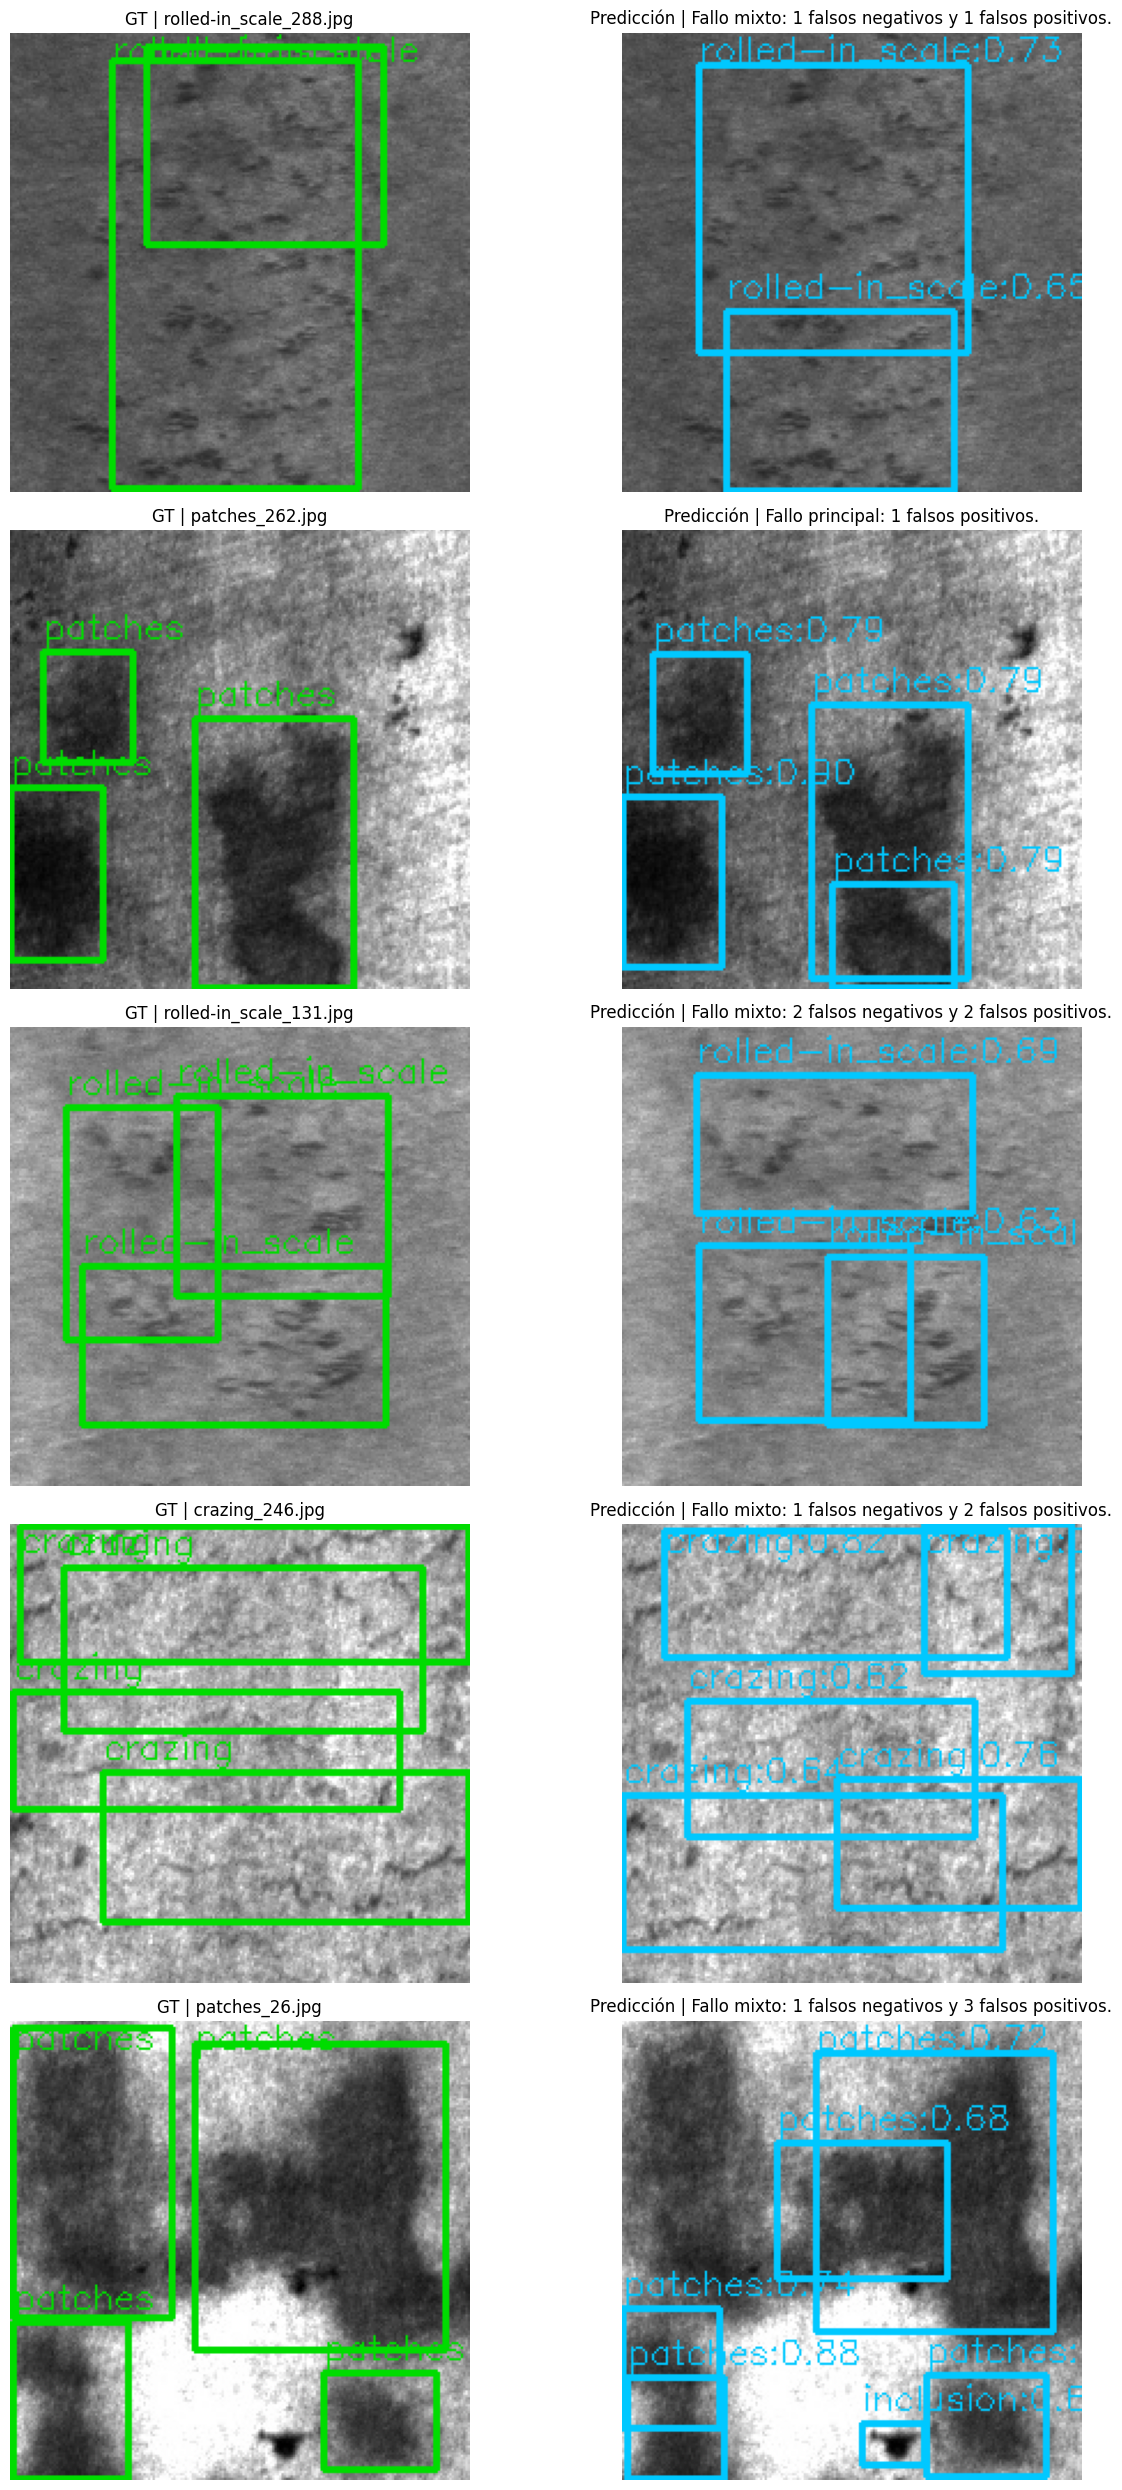

In [10]:
def draw_boxes(img_bgr, boxes, class_names, color=(0, 255, 0)):
    out = img_bgr.copy()
    for b in boxes:
        x1, y1, x2, y2 = b["box"]
        class_id = int(b["class_id"])
        name = class_names[class_id] if class_id < len(class_names) else str(class_id)
        conf = b.get("conf", None)
        label = f"{name}" if conf is None else f"{name}:{conf:.2f}"
        cv2.rectangle(out, (x1, y1), (x2, y2), color, 2)
        cv2.putText(out, label, (x1, max(12, y1 - 6)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)
    return out


def diagnose_failure(gts, preds, iou_thr=0.5):
    if len(gts) == 0 and len(preds) == 0:
        return "Sin objetos en GT y sin predicciones."
    if len(gts) > 0 and len(preds) == 0:
        return "Fallo principal: falso negativo (no detecta defectos)."
    if len(gts) == 0 and len(preds) > 0:
        return "Fallo principal: falso positivo (detecta donde no hay defecto)."

    matched_gt = set()
    matched_pred = set()
    class_errors = 0

    for pi, p in enumerate(preds):
        best_iou = 0.0
        best_gi = -1
        for gi, g in enumerate(gts):
            if gi in matched_gt:
                continue
            iou = _box_iou_np(p["box"], g["box"])
            if iou > best_iou:
                best_iou = iou
                best_gi = gi

        if best_gi >= 0 and best_iou >= iou_thr:
            matched_pred.add(pi)
            matched_gt.add(best_gi)
            if preds[pi]["class_id"] != gts[best_gi]["class_id"]:
                class_errors += 1

    fn = len(gts) - len(matched_gt)
    fp = len(preds) - len(matched_pred)

    if class_errors > 0:
        return f"Fallo principal: confusión de clase ({class_errors} casos)."
    if fn > 0 and fp > 0:
        return f"Fallo mixto: {fn} falsos negativos y {fp} falsos positivos."
    if fn > 0:
        return f"Fallo principal: {fn} falsos negativos."
    if fp > 0:
        return f"Fallo principal: {fp} falsos positivos."
    return "Predicción correcta (emparejamientos IoU>=0.5)."


def show_5_real_comparisons_improved(
    weights: Path,
    test_root: Path,
    threshold: float = 0.6,
    iou_thr: float = 0.5,
    nms_iou_thr: float = 0.30,
    n_show: int = 5,
    seed: int = 42,
):
    ckpt = torch.load(weights, map_location=DEVICE)
    class_names = ckpt.get("class_names", NEU_CLASSES)
    s = int(ckpt.get("s", GRID_SIZE))
    num_classes = int(ckpt.get("num_classes", len(class_names)))
    image_size = int(ckpt.get("image_size", IMAGE_SIZE))

    model = CustomSteelDetectorImproved(s=s, num_classes=num_classes).to(DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    images = _list_test_images(test_root)
    if len(images) == 0:
        raise FileNotFoundError(f"No hay imágenes en {test_root}")

    rng = np.random.default_rng(seed)
    if len(images) <= n_show:
        chosen = images
    else:
        idxs = rng.choice(len(images), size=n_show, replace=False)
        chosen = [images[int(i)] for i in idxs]

    fig, axes = plt.subplots(len(chosen), 2, figsize=(14, 5 * len(chosen)))
    if len(chosen) == 1:
        axes = np.array([axes])

    for row, image_path in enumerate(chosen):
        raw = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
        if raw is None:
            continue

        gts = _read_gt_boxes(image_path, class_names)
        preds = _predict_boxes(model, image_path, threshold=threshold, nms_iou_thr=nms_iou_thr, s=s, image_size=image_size)
        failure_text = diagnose_failure(gts, preds, iou_thr=iou_thr)

        left = draw_boxes(raw, gts, class_names, color=(0, 220, 0))
        right = draw_boxes(raw, preds, class_names, color=(255, 200, 0))

        axes[row, 0].imshow(cv2.cvtColor(left, cv2.COLOR_BGR2RGB))
        axes[row, 0].set_title(f"GT | {image_path.name}")
        axes[row, 0].axis("off")

        axes[row, 1].imshow(cv2.cvtColor(right, cv2.COLOR_BGR2RGB))
        axes[row, 1].set_title(f"Predicción | {failure_text}")
        axes[row, 1].axis("off")

    plt.tight_layout()
    plt.show()


VIS_WEIGHTS = Path("../src/custom_steel_detector_grid14_mejorado.pth")
VIS_TEST_DIR = Path("../data/test")

if VIS_WEIGHTS.exists() and VIS_TEST_DIR.exists():
    show_5_real_comparisons_improved(
        weights=VIS_WEIGHTS,
        test_root=VIS_TEST_DIR,
        threshold=0.6,
        iou_thr=0.5,
        nms_iou_thr=0.30,
        n_show=5,
    )
else:
    print("[WARN] No se pudo ejecutar visualización: revisa VIS_WEIGHTS y VIS_TEST_DIR")